[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hi-oz/obesity-level-estimation-regression/blob/main/TR/Regresyon_Analizi_Obezite.ipynb)

# Obezite Seviyelerinin Tahmini: Kapsamlı Regresyon Analizi

## Proje Özeti
Bu projede, beslenme alışkanlıkları ve fiziksel duruma dayalı obezite seviyelerini tahmin etmeye yönelik veri setini analiz edeceğiz. Projeyi iki ana hedefe böldük:
1. **Binary Sınıflandırma (Logistic Regression):** Sadece yaşam tarzı ve beslenme alışkanlıklarına bakarak bir kişinin obez olup olmadığını tahmin edebilir miyiz?
2. **Ordinal Sınıflandırma (Multiple Linear Regression):** 7 farklı obezite evresini (ordinal kategoriler) sürekli değişken (continuous) gibi ele alıp, Data-Driven karar sınırları (decision boundaries) üreterek standart bir doğrusal algoritmanın (MLR) sınırlarını ne kadar zorlayabiliriz?

Analiz boyunca Feature Engineering adımlarına ağırlık verecek, Data Leakage (Veri Sızıntısı) risklerini önleyecek ve modellerimiz zayıf kaldığında arka plandaki matematiksel kısıtlamaları yorumlayacağız.

---

## Adım 1: Veri Yükleme ve Sütun İsimlendirmeleri

Veri setini doğrudan UCI Machine Learning Repository'den çekerek başlıyoruz. Orijinal veri setindeki "FAVC", "FCVC" gibi İspanyolca kısaltmaları, analizi daha şeffaf ve okunabilir kılmak için İngilizce karşılıklarıyla değiştireceğiz.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Veri setini çekiyoruz
obesity_dataset = fetch_ucirepo(id=544)

# Feature ve Target değişkenleri ayırıyoruz
X = obesity_dataset.data.features
y = obesity_dataset.data.targets

# Exploratory Data Analysis (EDA) için veriyi tek bir DataFrame'de birleştiriyoruz
df = pd.concat([X, y], axis=1)

# Daha sezgisel bir analiz için sütun isimlerini güncelliyoruz
column_mapping = {
    "FAVC": "high_calorie_food",
    "FCVC": "vegetable_consumption",
    "NCP": "main_meals_count",
    "CAEC": "snacks_between_meals",
    "CH2O": "water_intake",
    "SCC": "calorie_monitoring",
    "FAF": "physical_activity_freq",
    "TUE": "tech_device_time",
    "CALC": "alcohol_consumption",
    "MTRANS": "transportation_method",
    "NObeyesdad": "obesity_level"
}

df.rename(columns=column_mapping, inplace=True)

# İsimlendirmeleri kontrol etmek için ilk 5 satıra bakalım
display(df.head())

,Gender,Age,Height,Weight,family_history_with_overweight,high_calorie_food,vegetable_consumption,main_meals_count,snacks_between_meals,SMOKE,water_intake,calorie_monitoring,physical_activity_freq,tech_device_time,alcohol_consumption,transportation_method,obesity_level
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


---

## Adım 2: Exploratory Data Analysis (EDA)

Herhangi bir transformasyon işleminden önce verinin yapısını anlamamız gerekiyor. Eksik değerleri (missing values) kontrol edecek, veri tiplerine bakacak ve dağılımları inceleyerek olası yanlılıkları (bias) tespit edeceğiz.

In [2]:
# Veri yapısı ve tipleri
print("Dataset Information:")
display(df.info())

# Null değer kontrolü
print("\nMissing Values:")
display(df.isnull().sum())

# Sayısal feature'lar için istatistiksel özet
print("\nStatistical Summary:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   high_calorie_food               2111 non-null   object 
 6   vegetable_consumption           2111 non-null   float64
 7   main_meals_count                2111 non-null   float64
 8   snacks_between_meals            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  water_intake                    2111 non-null   float64
 11  calorie_monitoring              2111 non-null   object 
 12  physical_acti

None


Missing Values:


Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
high_calorie_food                 0
vegetable_consumption             0
main_meals_count                  0
snacks_between_meals              0
SMOKE                             0
water_intake                      0
calorie_monitoring                0
physical_activity_freq            0
tech_device_time                  0
alcohol_consumption               0
transportation_method             0
obesity_level                     0
dtype: int64


Statistical Summary:


,Age,Height,Weight,vegetable_consumption,main_meals_count,water_intake,physical_activity_freq,tech_device_time
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


**Veri Yapısına Dair İçgörüler:**
* Veri setinde 2,111 satır ve 17 sütun bulunuyor.
* Hiç Null değer yok; bu bizi karmaşık imputation adımlarından kurtarıyor.
* Sayısal feature'ların ölçekleri (scale) arasında devasa farklar var. Örneğin "Age" 61'e kadar çıkarken "water_intake" 1 ile 3 arasında. Gradient Descent tabanlı modellerin (Logistic Regression gibi) büyük sayılardan etkilenmemesi için ileride mutlaka Feature Scaling yapmamız gerekecek.

### 2.1 Target Değişkenin Dağılımı

Target değişkenimiz ("obesity_level") **ordinal** bir yapıya sahip. Mantıksal bir ilerlemesi var (Zayıf $\rightarrow$ Normal $\rightarrow$ Fazla Kilolu $\rightarrow$ Obez). Bunu standart bir string değişken olarak bırakırsak grafiklerde rastgele sıralanır. Sıralamayı korumak için `pd.Categorical` kullanıyoruz.

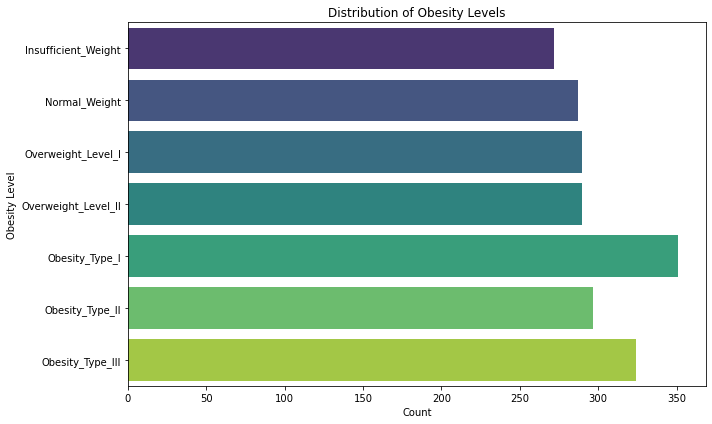

In [3]:
# Obezite seviyelerinin mantıksal sıralamasını tanımlıyoruz
obesity_order = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III"
]

# Değişkeni sıralı (ordered) bir categorical veri tipine dönüştürüyoruz
df["obesity_level"] = pd.Categorical(df["obesity_level"], categories=obesity_order, ordered=True)

plt.figure(figsize=(10, 6))
sns.countplot(data=df, y="obesity_level", palette="viridis")
plt.title("Distribution of Obesity Levels")
plt.xlabel("Count")
plt.ylabel("Obesity Level")
plt.tight_layout()
plt.show()

**Target Dağılımının Yorumu:**
Countplot bize fazlasıyla dengeli bir veri seti gösteriyor; her sınıfın yaklaşık 270-350 örneği var. Gerçek dünyadaki klinik verilerde "Tip III Obezite" genelde azınlık sınıfı (minority class) olur. Bu denge, veri setini hazırlayanların muhtemelen SMOTE gibi sentetik veri üretim teknikleri kullandığını gösteriyor. Sentetik verilerin analizde bazen yapay bias'lar yaratabileceğini aklımızda tutmalıyız.

### 2.2 Sayısal Özellikler vs. Target Değişken

Temel fiziksel özelliklerin (Yaş, Boy, Kilo) obezite seviyeleriyle ilişkisine bakalım. Medyanları, varyansı ve outlier'ları (aykırı değerler) görmek için Boxplot iyi bir tercih.

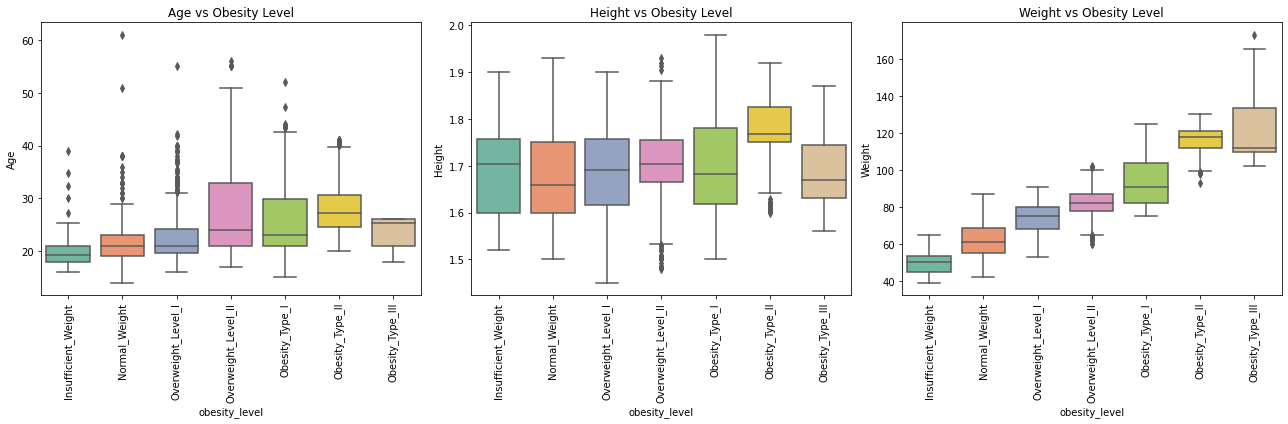

In [4]:
# 3 alt grafikten oluşan bir figür hazırlıyoruz
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Age (Yaş)
sns.boxplot(ax=axes[0], data=df, x="obesity_level", y="Age", palette="Set2")
axes[0].set_title("Age vs Obesity Level")
axes[0].tick_params(axis="x", rotation=90)

# Height (Boy)
sns.boxplot(ax=axes[1], data=df, x="obesity_level", y="Height", palette="Set2")
axes[1].set_title("Height vs Obesity Level")
axes[1].tick_params(axis="x", rotation=90)

# Weight (Kilo)
sns.boxplot(ax=axes[2], data=df, x="obesity_level", y="Weight", palette="Set2")
axes[2].set_title("Weight vs Obesity Level")
axes[2].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

**Boxplot Yorumları ve Data Leakage (Veri Sızıntısı) Uyarısı:**
* **Age:** Bütün sınıflara dağılmış durumda, ancak "Obesity Type II" görece biraz daha yaşlı bir demografik profile sahip.
* **Height:** Sınıflar arasında varyansı çok düşük ve tutarlı.
* **Weight (Kritik Bulgu):** Weight grafiği kusursuz bir merdiven gibi yükseliyor. Kilo arttıkça obezite artıyor. Bu durum **Data Leakage** için devasa bir alarmdır. Tıpta obezite doğrudan Vücut Kitle İndeksi (BMI) formülüyle ($Weight / Height^2$) hesaplanır. Eğiteceğimiz modele Weight sütununu verirsek, model insanların yaşam alışkanlıklarını öğrenmek yerine dümdüz BMI formülünü hesaplayıp kopya çekecektir.

### 2.3 Outlier (Aykırı Değer) Analizi: Neden Silmedik?

Yukarıdaki grafiklerde (özellikle Age ve Height kısımlarında) siyah elmasla gösterilen birçok outlier (aykırı değer) dikkatinizi çekmiştir. Standart eğitimlerde IQR gibi yöntemlerle bu verilerin silinmesi veya baskılanması (capping) tavsiye edilir. Ancak biz bunları bilinçli olarak veride tuttuk. Neden mi?

1. **Noise (Gürültü) Değil, Sinyalin Kendisi:** Bir outlier ancak hatalı girildiyse (örn: Yaş=250) silinir. Bizim verimizdeki 60 yaşındaki bir hasta veya ekstrem boya sahip bir birey gerçek bir biyolojik varyasyondur. Doğal insan çeşitliliğini silersek modelin gerçek dünyayı anlama kapasitesini yapay olarak kısıtlamış oluruz.
2. **Ekstrem Sınıfları Korumak:** Matematiksel bir outlier temizliği yapsaydık, "Obesity_Type_II" veya "Type III" sınıflarındaki birçok hastayı (verinin en uç noktalarını) silmek zorunda kalırdık. Bu da modelin ekstrem demografilere karşı körleşmesine neden olurdu.
3. **Sentetik Verinin Doğası:** Veri seti büyük ihtimalle SMOTE ile dengelenmiş bir set. O gördüğünüz outlier'ların çoğu, makine öğrenmesi algoritmasının azınlık (minority) sınıfları daha iyi öğrenebilmesi için özel olarak üretilmiş sentetik profiller olabilir. Onları silmek, veriyi en başta sentetik olarak dengeleyen veri mühendislerinin amacına tamamen ters düşer.

*Özetle:* Data Science projelerinde bir veriyi silmeden önce neden orada olduğunu sorgulamak gerekir. Bu verideki fiziksel uç değerler, hedeflediğimiz ekstrem sınıfları tanımlayan çok değerli özelliklerdir.

---

## Adım 3: Feature Engineering ve Preprocessing

Modeller metin değil sayı ister. İlk analizimiz için kategorik değişkenlerimizi encode edecek, sürekli değişkenlerimizi (continuous variables) scale edecek ve ikili (binary) bir target oluşturacağız.

### 3.1 Binary Target Oluşturma ve Encoding

Logistic Regression modelimiz için sadece "Obez" ve "Obez Değil" tahmini yapacağız. Tip I, II ve III'ü `1`, geri kalan her şeyi `0` yapıyoruz. Ayrıca Multicollinearity riskini (Dummy Variable Trap) önlemek için kategorik feature'larda One-Hot Encoding kullanıp ilk sütunu drop'layacağız (`drop_first=True`).

In [5]:
# Logistic Regression için Binary Target oluşturuyoruz
obese_categories = ["Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"]
df["is_obese"] = df["obesity_level"].apply(lambda x: 1 if x in obese_categories else 0)

# Binary (Evet/Hayır) formatındaki sütunları doğrudan 0 ve 1'e map'liyoruz
binary_mapping = {"yes": 1, "no": 0}
binary_cols = ["family_history_with_overweight", "high_calorie_food", "SMOKE", "calorie_monitoring"]

for col in binary_cols:
    df[col] = df[col].map(binary_mapping)

# Gender sütunu için özel mapping
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

# Kalan nominal değişkenler için One-Hot Encoding yapıyoruz
multi_class_cols = ["snacks_between_meals", "alcohol_consumption", "transportation_method"]

# Original target sütunlarını atarak ana matrisi (X) hazırlıyoruz
X_raw = df.drop(columns=["obesity_level", "is_obese"])

# One-hot encoding işlemi
X_encoded = pd.get_dummies(X_raw, columns=multi_class_cols, drop_first=True)

### 3.2 Feature Scaling

Verilerin dağılımını 0 ortalama ve 1 standart sapmaya getirmek için `StandardScaler` kullanacağız. Bu sayede sayısal olarak büyük değerler barındıran özellikler (örn: Weight), küçük rakamlı özellikleri (örn: water_intake) manipüle edemeyecek.

In [6]:
from sklearn.preprocessing import StandardScaler

numerical_cols = ["Age", "Height", "Weight", "vegetable_consumption",
                  "main_meals_count", "water_intake", "physical_activity_freq",
                  "tech_device_time"]

scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_scaled[numerical_cols] = scaler.fit_transform(X_scaled[numerical_cols])

---

## Adım 4: Logistic Regression (Binary Classification)

### 4.1 Modeli Data Leakage'dan Koruma

EDA bölümünde fark ettiğimiz üzere, "Weight" sütununu modelde bırakırsak model sadece BMI formülünü hesaplayıp kopya çekecektir. İşin doğası gereği, *"Sadece yaşam tarzı alışkanlıklarına bakarak obeziteyi tahmin edebilir miyiz?"* sorusuna yanıt aradığımız için "Weight" sütununu tamamen kaldırıyoruz. Boy (Height) tek başına obeziteyi belirleyemeyeceği için veride kalmasında sakınca yok.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Data leakage'ı önlemek için Weight sütununu atıyoruz
X_scaled_no_leakage = X_scaled.drop(columns=["Weight"])
y_binary = df["is_obese"]

# Train/Test split işlemini class imbalance olmaması için stratify ile yapıyoruz
X_train_nl, X_test_nl, y_train_nl, y_test_nl = train_test_split(
    X_scaled_no_leakage, 
    y_binary, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_binary
)

# Realistic (leakage olmayan) modeli eğitme
log_reg_nl = LogisticRegression(random_state=42, max_iter=1000)
log_reg_nl.fit(X_train_nl, y_train_nl)

# Tahmin ve değerlendirme
y_pred_log_nl = log_reg_nl.predict(X_test_nl)
accuracy_nl = accuracy_score(y_test_nl, y_pred_log_nl)

print(f"Realistic Logistic Regression Accuracy: {accuracy_nl:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_nl, y_pred_log_nl, target_names=["Not Obese (0)", "Obese (1)"]))

Realistic Logistic Regression Accuracy: 0.7541

Classification Report:
               precision    recall  f1-score   support

Not Obese (0)       0.84      0.68      0.75       228
    Obese (1)       0.69      0.85      0.76       195

     accuracy                           0.75       423
    macro avg       0.76      0.76      0.75       423
 weighted avg       0.77      0.75      0.75       423



**Modelin Değerlendirilmesi:**
Kilo değişkenini veriden attığımızda yaklaşık **%75** civarında çok gerçekçi bir accuracy elde ediyoruz. %99'luk bir tahmin değil ama oldukça değerli bir metrik. Sadece hastanın sebze yeme, ekran süresi ve yürüme alışkanlıklarına bakarak, hastanın obez olup olmadığını 4 seferin 3'ünde doğru tahmin edebiliyoruz.

### 4.2 Modeli Yorumlama: ROC Eğrisi ve Feature Importance

Modelin bu %75'i nasıl yakaladığını görmek için önce sınıf ayrımı yeteneğini (ROC) ölçecek, ardından hangi alışkanlıkların daha etkili olduğunu görmek için katsayılara (coefficients) bakacağız.

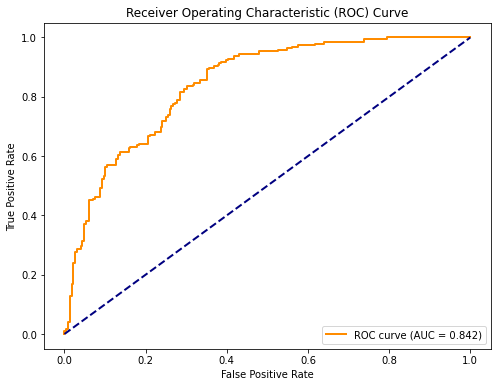

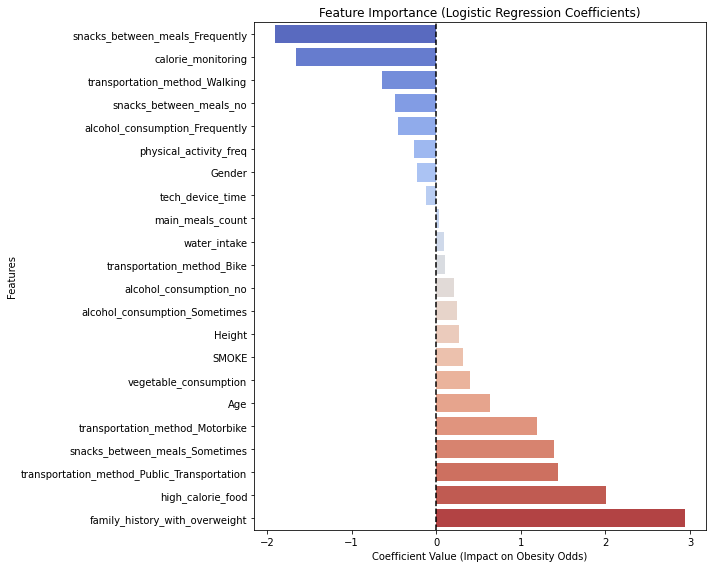

In [8]:
from sklearn.metrics import roc_curve, auc

# 1. ROC Eğrisi Çizimi
y_pred_proba = log_reg_nl.predict_proba(X_test_nl)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_nl, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()

# 2. Feature Katsayılarının Çıkarılması (Feature Importance)
coefficients = log_reg_nl.coef_[0]
feature_names = X_train_nl.columns

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=True)

plt.figure(figsize=(10, 8))
sns.barplot(x="Coefficient", y="Feature", data=coef_df, palette="coolwarm")
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value (Impact on Obesity Odds)")
plt.ylabel("Features")
plt.axvline(x=0, color="black", linestyle="--")
plt.tight_layout()
plt.show()

**Grafiklerin Analizi:**

1. **ROC Eğrisi (AUC = 0.842):** Eğrinin altında kalan alan 0.84. Sadece fiziksel alışkanlıklara bakarak sınıf ayırma konusunda modelimizin son derece güvenilir olduğunu kanıtlıyor.
2. **Pozitif Katsayılar (Kırmızı - Risk Faktörleri):** Model diyor ki; "family_history_with_overweight" obezitenin en büyük tetikleyicisidir. Genetik burada başrol oynuyor. Bunu takiben "high_calorie_food" (yüksek kalori) ve "transportation_method_Public_Transportation" (hareketsiz bir ulaşım stili) obezite riskini ciddi oranda artırıyor.
3. **Negatif Katsayılar (Mavi - Koruyucu Faktörler):** "calorie_monitoring" (kalori sayma) ve "transportation_method_Walking" (yürüme) obezite riskini ciddi oranda düşürüyor.
4. **"Alkol" Anomalisi:** Çıkan katsayılara göre "alcohol_consumption_Frequently" değişkeni çok güçlü bir koruyucu faktör (mavi). Oysa biyolojik olarak alkol yüksek kalorilidir.
   * *Neden böyle oldu?* "Correlation is not causation" (Korelasyon nedensellik değildir). Alkol kullanımına "Sıklıkla" (Frequently) yanıtı veren kitle muhtemelen genç ve çok hareketli olan üniversite öğrencileri demografisinden geliyor. Yüksek sosyal hayat (veride olmayan gizli bir değişken) bu kitleyi zayıf tutuyor; model de alkolün insanı zayıf tuttuğu gibi yanlış bir nedensellik kuruyor. Makine öğrenmesi çıktılarının bir Domain Expert (Alan Uzmanı) tarafından yorumlanmasının önemi tam olarak budur.

---

## Adım 5: Multiple Linear Regression (MLR) ile Ordinal Sınıflandırma

Binary problemi çözdük. Şimdi çok daha zor bir challenge'a giriyoruz: Sınıfları Insufficient Weight'ten Type III'e kadar tam 7 aşama halinde tahmin etmek.

Bu sınıflar arasında kesin bir matematiksel hiyerarşi olduğu için onları tamsayılara (0-6) map'leyip standart bir Çoklu Doğrusal Regresyon (MLR) modeline vererek sınırları zorlayacağız.

### 5.1 Ordinal Görev İçin Bias Temizliği

"Weight" değişkeninin sızıntı yaptığını zaten biliyoruz. Ayrıca sentetik olarak oluşturulan bu veride "Obesity_Type_III" vakalarının neredeyse hepsi kadınken, "Obesity_Type_II" vakaları erkektir. Doğrusal modelin bu sentetik ve gerçek dışı bias üzerinden kolay yoldan puan toplamasını (kopya çekmesini) engellemek için hem "Weight" hem de "Gender" değişkenlerini düşürüyoruz.

In [9]:
# Ordinal target değişkenini 0-6 arası integer'lara map'liyoruz
ordinal_mapping = {
    "Insufficient_Weight": 0, "Normal_Weight": 1, "Overweight_Level_I": 2,
    "Overweight_Level_II": 3, "Obesity_Type_I": 4, "Obesity_Type_II": 5, "Obesity_Type_III": 6
}
y_ordinal = df["obesity_level"].map(ordinal_mapping)

# Leakage yapan Weight ve sentetik bias yaratan Gender sütunlarını düşürüyoruz
X_mlr_optimized = X_scaled.drop(columns=["Weight", "Gender"])

### 5.2 Non-Linearity (Doğrusal Olmama) Problemi ve Polynomial Features

Eğer buraya standart bir MLR kurarsak accuracy %25'lere çakılır. **Neden?** Çünkü Linear Regression modelleri MSE'yi (Mean Squared Error) minimize etmeye çalışır. Model devasa hata cezalarından kaçmak için ekstrem uçları (0 ve 6'yı) tahmin etmeye korkar ve tüm tahminleri ortalamaya (3-4 arasına) sıkıştırır. Buna "Regression to the mean" denir.

İnsan biyolojisi düz bir çizgi (lineer) şeklinde ilerlemez. Bu lineer mimariyi terk etmeden esneklik katmak için **Polynomial Features (Degree 2)** kullanacağız. Bu sayede feature'ların karesi (örn: $Age^2$) ve birbirleriyle etkileşimleri (örn: $Height \times water\_intake$) modele eklenecek, doğrusal düzlemimiz eğrilip bükülerek kompleks insan verisine fit olabilecek. Curse of dimensionality (boyutluluğun laneti) ve aşırı öğrenmeden (overfitting) kaçınmak için 3. dereceden (Degree 3) uzak duruyoruz.

In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV

# 1. Polynomial Features (Degree 2) oluşturuyoruz
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_mlr_optimized)

# 2. Polinom ile genişlemiş veriyi train/test olarak ayırıyoruz
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly, y_ordinal, test_size=0.2, random_state=42, stratify=y_ordinal
)

### 5.3 Ridge (L2) Regularization ile Multicollinearity'i Dizginlemek

Polynomial Features ekleyerek modele esneklik kattık ama başımıza büyük bir istatistiksel sorun çıkardık: **Multicollinearity (Çoklu Doğrusal Bağlantı)**. Modelde hem $Age$ hem de $Age^2$ olduğu için bunlar birbiriyle yüksek korelasyon gösterip katsayıları anlamsızca şişirecek ve modeli stabil olmaktan çıkaracaktır.

Çözüm olarak **Ridge Regression (L2 Regularization)** kullanıyoruz. Ridge, aşırı şişen katsayıları matematiksel olarak cezalandırıp aşağı çekerek modelin varyansını düşürür. Optimal ceza (penalty - $\alpha$) katsayısını manuel aramak yerine, Cross-Validation (Çapraz Doğrulama) yapan `RidgeCV` kullanıyoruz.

In [11]:
# Cross-Validation ile Ridge modelini eğitiyoruz
alphas_to_test = [0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_cv = RidgeCV(alphas=alphas_to_test)
ridge_cv.fit(X_train_poly, y_train_poly)

print(f"Optimal Alpha (Penalty) selected by Cross-Validation: {ridge_cv.alpha_}")

Optimal Alpha (Penalty) selected by Cross-Validation: 10.0


### 5.4 Data-Driven (Veri Odaklı) Karar Sınırları Üretmek

Ridge modeli katsayıları baskıladığı için, nihai tahminlerin (predictions) varyansını da ezip daraltır. Artık model Obezite Tip III bir hasta için 6.0 değil, 4.8 gibi değerler üretecektir. Eğer sonuçları klasik `np.round()` ile tam sayıya yuvarlarsak, 4.8 değeri 5'e (Tip II) yuvarlanır ve en uç sınıf olan Tip III'ü asla bulamayız.

Threshold'ları (eşikleri) ezbere "sihirli sayılarla" belirlemek yerine, **Dinamik Karar Sınırları (Dynamic Decision Boundaries)** oluşturacağız. Training verisindeki gerçek sınıfların ortalama sürekli tahmin (continuous prediction) değerlerini bulup, karar sınırlarını tam olarak bu ortalamaların orta noktalarına (midpoint) oturtacağız.

Data-Driven Ridge MLR - Mean Absolute Error (MAE): 0.9078
Data-Driven Ridge MLR - Exact Match Accuracy: 0.4137



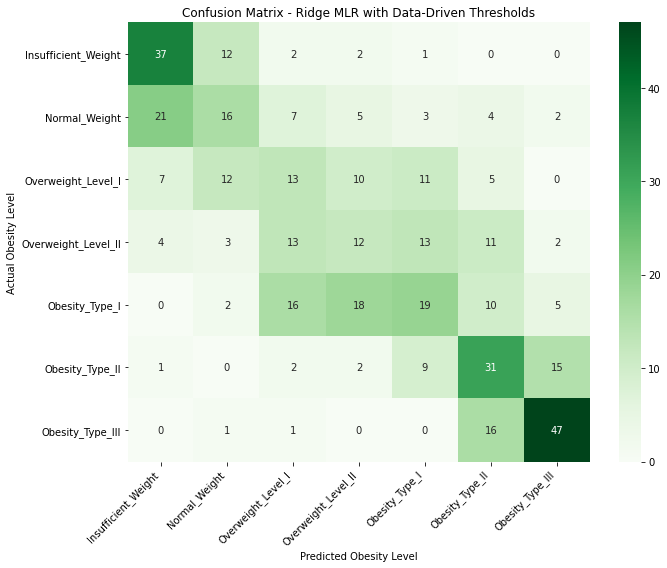

In [12]:
from sklearn.metrics import mean_absolute_error

# 1. Eğitim (TRAIN) setindeki sınıf ortalamalarını hesaplıyoruz (Test setinde yapmak data leakage'a girer!)
y_train_pred_cont = ridge_cv.predict(X_train_poly)
train_analysis = pd.DataFrame({"Actual_Class": y_train_poly, "Raw_Prediction": y_train_pred_cont})
class_means = train_analysis.groupby("Actual_Class")["Raw_Prediction"].mean()

# 2. Sınıf ortalamalarının tam orta noktalarını bularak threshold (eşik) dizisi oluşturuyoruz
dynamic_thresholds = []
for i in range(len(class_means) - 1):
    midpoint = (class_means.iloc[i] + class_means.iloc[i+1]) / 2
    dynamic_thresholds.append(midpoint)

# 3. Bu dinamik eşikleri kullanarak sürekli değerleri sınıflara (0-6) bölen fonksiyon
def dynamic_ordinal_rounding(pred, thresholds):
    if pred < thresholds[0]: return 0
    elif pred < thresholds[1]: return 1
    elif pred < thresholds[2]: return 2
    elif pred < thresholds[3]: return 3
    elif pred < thresholds[4]: return 4
    elif pred < thresholds[5]: return 5
    else: return 6

# 4. Dinamik yuvarlamayı TEST setindeki sürekli tahmin değerlerine uyguluyoruz
y_pred_cont_ridge = ridge_cv.predict(X_test_poly)
vectorized_dynamic = np.vectorize(lambda x: dynamic_ordinal_rounding(x, dynamic_thresholds))
y_pred_ridge_dynamic = vectorized_dynamic(y_pred_cont_ridge)

# 5. Model metriklerini (MAE ve Accuracy) değerlendiriyoruz
mae_dynamic = mean_absolute_error(y_test_poly, y_pred_ridge_dynamic)
accuracy_dynamic = accuracy_score(y_test_poly, y_pred_ridge_dynamic)

print(f"Data-Driven Ridge MLR - Mean Absolute Error (MAE): {mae_dynamic:.4f}")
print(f"Data-Driven Ridge MLR - Exact Match Accuracy: {accuracy_dynamic:.4f}\n")

# 6. Son Confusion Matrix görselleştirmesi
class_names = list(ordinal_mapping.keys())
plt.figure(figsize=(10, 8))
cm_dynamic = confusion_matrix(y_test_poly, y_pred_ridge_dynamic)
sns.heatmap(cm_dynamic, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names)

plt.title("Confusion Matrix - Ridge MLR with Data-Driven Thresholds")
plt.xlabel("Predicted Obesity Level")
plt.ylabel("Actual Obesity Level")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 5.5 Son Yorum ve Alternatif Yaklaşımlar

**Sonuçların Analizi:**
İlk bakışta **~%41** civarındaki bir Exact Match Accuracy (Birebir Eşleşme) değeri, standart ML sınıflandırma projelerine kıyasla zayıf görünebilir. Ancak 7 farklı evreyi tahmin eden bir "Ordinal Lineer Regresyon" yapısı kurduğumuzu düşündüğümüzde, bu tam anlamıyla bir Feature Engineering şovudur.

* **Mean Absolute Error (MAE) 0.90:** Gerçek başarı metriğimiz budur. Model bir tahmin hatası yaptığında, ortalamada hastanın seviyesini **1 evreden bile daha az** saptırıyor (Örn: Gerçekte Tip I iken, Overweight Level II tahmini yapıyor).
* **Confusion Matrix Köşegeni (Diagonal):** Geliştirdiğimiz "Data-Driven" threshold'lar sayesinde model, "Ortalamaya Gerileme (Regression to the mean)" kâbusunu atlattı. Standart lineer modellerin tamamen korkup sıfır çektiği 47 adet `Obesity_Type_III` ve 37 adet `Insufficient_Weight` gibi en uç sınıfları başarıyla teşhis etti.

**Alternatifler:**
Bu projede amacımız, zorlu ve doğrusal olmayan (non-lineer) bir problemi alıp; Regularization, Polynomial Expansion ve Threshold Engineering (Eşik Mühendisliği) gibi ileri seviye teknikleri sergilemek adına bilerek katı bir doğrusal (MLR) algoritmaya çözdürmekti.

Eğer bu projenin tek ve yegane amacı "en yüksek accuracy" değerine ulaşmak olsaydı, Lineer Regresyon yerine doğrudan **Tree-Based (Ağaç Tabanlı)** modellere (örneğin **Random Forest** veya **XGBoost**) geçerdik. Karar ağaçları (Decision trees) karmaşık ilişkileri, Multicollinearity'i ve çoklu sınıfları (multi-class) doğası gereği mükemmel şekilde yönetir. Özel threshold'lar uydurmamıza veya polinomlar oluşturmamıza gerek kalmazdı. Ek olarak, direkt sıralı (ordinal) kategoriler için tasarlanmış **Ordinal Logistic Regression (Proportional Odds Model)** kurmak, MLR'ı hackleyerek elde ettiğimiz çözümden matematiksel olarak çok daha stabil (native) bir çözüm sunardı.